# chessformer_lens short demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chessformer-lens/chessformer_lens/blob/main/demo.ipynb)

#### This notebook loads Maia-3, a chess transformer trained to mimic human play at a given rating, and investigates **which part of the network spots a knight fork?**

In [14]:
# install the maia engine which is not on PyPI and pip install the library
%pip install https://github.com/CSSLab/maia3/archive/1e13597c42d4858b7cfd7cfdae01e297263364b2.zip --quiet
%pip install chessformer_lens --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [15]:
import chess
import numpy as np
import matplotlib.pyplot as plt
from chessformer_lens import MaiaEngine, attention_widget
import chessformer_lens.interp_plot as ip

eng = MaiaEngine()        # maia with 5 million parameters
ip.set_theme("light")
print(f"{eng.cfg.num_blocks} layers, {eng.cfg.num_heads} heads, running on {eng.device}")

8 layers, 8 heads, running on mps


#### White's knight on g4 can jump to f6, giving check and attacking the queen on d7 known as a (royal) fork. The model takes the player's rating as an input, so we can ask how a 2400 player and an 700 player see the same board.

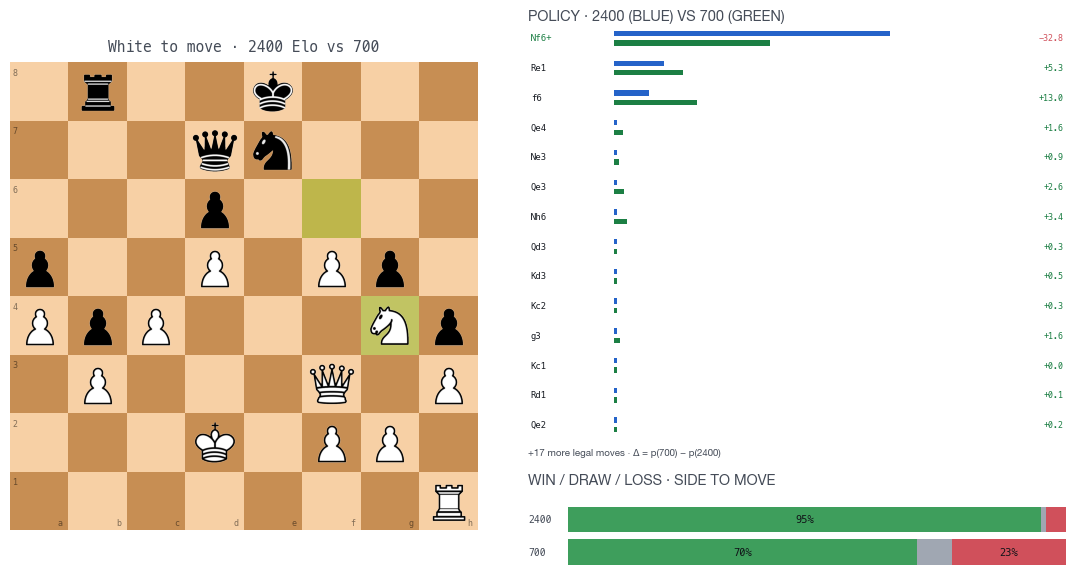

In [16]:
board = chess.Board("1r2k3/3qn3/3p4/p2P1Pp1/PpP3Np/1P3Q1P/3K1PP1/7R w - - 0 37")
fork = "g4f6"     # Nf6+

fig = ip.plot_position(eng, board, 2400, elo_b=700, played=fork)

#### **Using the engine methods directly:** to find the top moves for each Elo and their estimated win draw loss odds.

#### This style was inspired by Neel Nanda's TransformerLens library.

In [17]:
for elo in (2400, 700):
    out = eng.evaluate(board, elo)

    top3 = ", ".join(eng.move_info(board, uci)["san"] for uci, _ in out["policy"][:3])
    wdl = out["wdl"]

    print(f"{elo}:  {top3}   |   win {wdl['win']:.1%}  draw {wdl['draw']:.0%}  loss {wdl['loss']:.0%}")

2400:  Nf6+, Re1, f6   |   win 95.0%  draw 1%  loss 4%
700:  Nf6+, f6, Re1   |   win 69.7%  draw 7%  loss 23%


#### Use **logit lens** at every attention sub-layer (aN) and MLP sub-layer (mN) to trace the logit of the fork move. The dashed line marks where it becomes the model's top move. Here: attention layer 7.

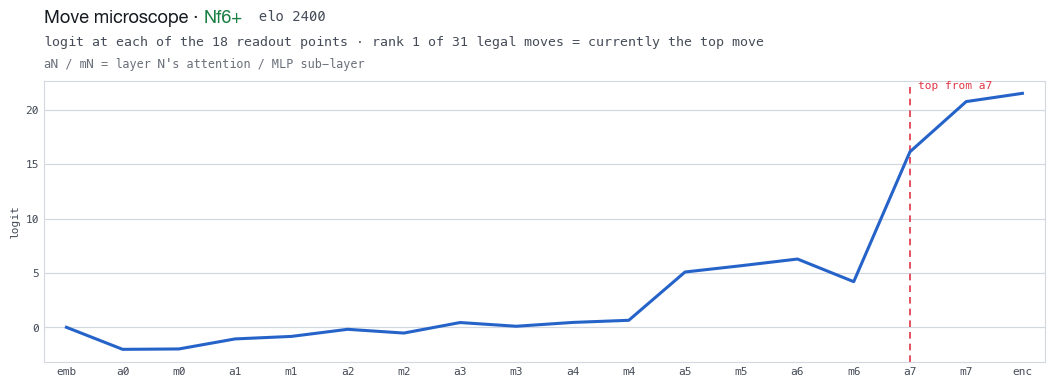

In [18]:
fig = ip.plot_move_microscope(eng, board, 2400, fork)

#### The plot uses `run_with_cache` and `logit_lens`. Calling them raw gives the same results.

In [19]:
out, cache = eng.run_with_cache(board, 2400)
print(f"{len(cache)} activations cached with dimensions {list(cache['attn_07'].shape)}") # This is directly inspired by Neel Nanda's Transformer Lens style

for name in ["block_01", "block_03", "block_05", "postattn_07", "encoder_out"]:
    lens = eng.logit_lens(cache[name], board)
    print(f"{name:12s} top move {lens['san']:5s}  logit {lens['logit']:.2f}")

34 activations cached with dimensions [64, 256]
block_01     top move Qe3    logit 2.33
block_03     top move Re1    logit 5.02
block_05     top move Re1    logit 9.53
postattn_07  top move Nf6+   logit 16.13
encoder_out  top move Nf6+   logit 21.50


#### The logit lens is correlational but does not show what is causally important for producing the output. We can remove an attention head's exact write to the residual stream, rerun the model, and measure how the move's logit changes for all heads. legend: blue carries the move, orange suppresses it.

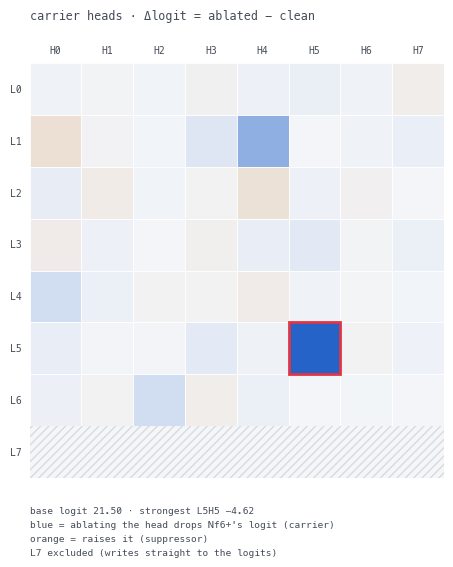

In [20]:
fig = ip.plot_carrier_heads(eng, board, 2400, fork)

#### Time to investigate layer 5 head 5

#### `ablate_grid_batch` runs the same sweep over many positions in a single batch. Here are ten knight forks, with both colors.

In [21]:
forks = [
    ("1r2k3/3qn3/3p4/p2P1Pp1/PpP3Np/1P3Q1P/3K1PP1/7R w - - 0 37", "g4f6"),
    ("5b2/6p1/3p2k1/2p3pn/7r/8/P2NKPQ1/R6R b - - 2 25", "h5f4"),
    ("6k1/5p1p/p3p1p1/1p2n3/1P1q4/P2p2P1/3Q1N1P/6K1 b - - 2 37", "e5f3"),
    ("rn1q1knr/pb2p1b1/6p1/5pN1/1pPP3p/1P6/P1B2PPP/1RQ2RK1 w - - 2 20", "g5e6"),
    ("5r1k/3nrBp1/b1pp1n1p/p3q2P/Pp2PN2/3PB1Q1/1PP3P1/2KR3R w - - 1 22", "f4g6"),
    ("6k1/1pq2ppp/p7/3p4/1P1Nn3/P2QPP2/1B4Pb/7K b - - 1 26", "e4f2"),
    ("4r1k1/6b1/3p2pp/3Pnp2/4N2Q/6P1/P1q2P1P/4R1K1 b - - 0 26", "e5f3"),
    ("5rk1/pp5p/2p1p1p1/6N1/3PQBP1/2q4P/P7/3n3K b - - 1 25", "d1f2"),
    ("r2q1rk1/ppp3p1/3ppn1B/2b1p3/3nP3/3P2QN/PPP2PPP/RN3RK1 b - - 2 11", "d4e2"),
    ("r1b2rk1/1pp2p1p/4p1p1/2PqP3/p1nPN2B/P1PQ4/6PP/R4RK1 w - - 2 21", "e4f6"),
]

boards_moves = [(chess.Board(fen), move) for fen, move in forks]

grids = eng.ablate_grid_batch(boards_moves, 2400)

deltas = np.array([g["deltas"] for g in grids])[:, :-1]   
mean = deltas.mean(axis=0) # getting the average difference in logit over all positions for each head in each layer

L, H = (int(i) for i in np.unravel_index(mean.argmin(), mean.shape))
wins = sum(np.unravel_index(d.argmin(), d.shape) == (L, H) for d in deltas)
print(f"Strongest carrier: layer {L} head {H}, mean Δlogit {mean[L, H]:+.2f}, "
      f"top head in {wins} of {len(forks)} positions")


# again we dont care about the layer right before the policy

Strongest carrier: layer 5 head 5, mean Δlogit -3.01, top head in 10 of 10 positions


#### Attention: Each token maps to one unique square, so attention maps are literally visualizable on the board. Its attention heads combine two schemes: the standard “semantic” self-attention, and a “geometric” GAB attention scheme which carries positional structure because chess pieces move in ways that complicate semantic only attention.

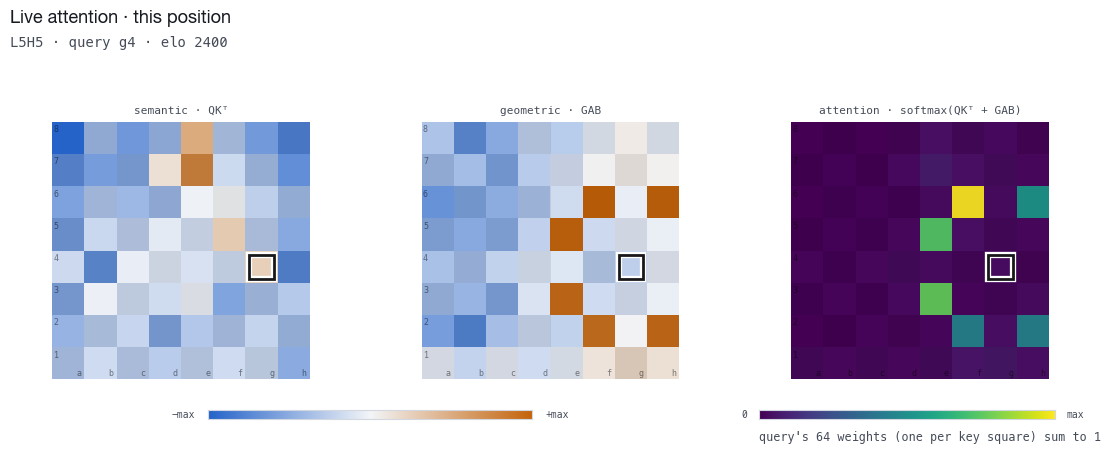

In [22]:
fig = ip.plot_attention(eng, board, 2400, layer=5, head=5, query="g4")

#### wow, optimization forced this attention head to learn a knight move pattern!

#### **Interactive heads cell:**

In [23]:
attention_widget(eng, board, 2400, layer=L, head=H)

#### Heads are quick to ablate one at a time in many forward passes but MLP neurons are not: this small model has 512 per MLP, each active on all 64 squares. We can use attribution patching, which cleverly uses backpropagation to quickly approximate each neuron's causal importance. Then test that with actual ablation.

In [24]:
result = eng.carrier_neurons(board, 2400, fork, top_k=5, verify=True)

for neuron in result["top"]:
    square = neuron["peak"]
    if board.turn == chess.BLACK:
        square = chess.square_mirror(square)   # the engine counts squares from the side to move
    print(f"Layer {neuron['layer']}, neuron {neuron['neuron']}: "
          f"estimated {neuron['est']:+.2f}, exact {neuron['exact']:+.2f}, "
          f"strongest on {chess.square_name(square)}")


Layer 6, neuron 436: estimated -0.17, exact -0.22, strongest on f6
Layer 6, neuron 158: estimated -0.17, exact -0.22, strongest on d7
Layer 6, neuron 21: estimated +0.23, exact +0.21, strongest on d7
Layer 3, neuron 376: estimated +0.21, exact +0.21, strongest on f5
Layer 6, neuron 63: estimated -0.17, exact -0.20, strongest on d7


#### **Another position.** Change the FEN and the move in the cell that sets board and fork, then rerun from there. For instance the famous Opera Game position: 
`fen = "4kb1r/p2n1ppp/4q3/4p1B1/4P3/1Q6/PPP2PPP/2KR4 w k - 0 16" `


#### help(ip) lists all the plotters

#### **Other models:** You can run `MaiaEngine("maia3-23m")` and `MaiaEngine("maia3-79m")` which have 16 and 32 heads per layer. `LeelaEngine()` is huge and needs its weights file. It is one of the strongest engines created.

#### **The desktop app.** Install locally and run `chessformer_lens` to play the model and click through all of this live.

#### [GitHub](https://github.com/chessformer-lens/chessformer_lens) · [Paper](https://arxiv.org/abs/2609.23917) · [App guide](https://github.com/chessformer-lens/chessformer_lens/blob/main/app_guide.md)